In [1]:
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
data=pd.read_csv("smartcart_customers.csv")

In [3]:
data.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


In [4]:
data.shape

(2240, 22)

In [5]:
data.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64

# DATA PREPROCESSING 



In [6]:
#HANDLING THE MISSING VALUES
data["Income"]=data["Income"].fillna(data["Income"].mean())

In [7]:
data.isnull().sum()

ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
Complain               0
Response               0
dtype: int64

In [8]:
#Age
data["Age"]=2026-data["Year_Birth"]

In [9]:
#customer joining date
data["Dt_Customer"]=pd.to_datetime(data["Dt_Customer"],dayfirst=True)
reference_date=data["Dt_Customer"].max()
data["total days"]=(reference_date-data["Dt_Customer"]).dt.days

In [10]:
data.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Age', 'total days'],
      dtype='object')

In [11]:
#Spending 
data["total_spending"]=data['MntWines']+data['MntFruits']+data['MntMeatProducts']+data['MntFishProducts']+data['MntSweetProducts']+data['MntGoldProds']

In [12]:
#Children
data["children"]=data['Kidhome']+data['Teenhome']

In [13]:
data["Education"]=data["Education"].replace({
    "Basic":"undergraduate", "2n Cycle":"undergraduate",
    "Master":"graduate", 
    "PhD":"postgraduate","Graduation":"postgraduate"
})

In [14]:
data["Education"].value_counts()

Education
postgraduate     1613
graduate          370
undergraduate     257
Name: count, dtype: int64

In [43]:
data["Marital_Status"].value_counts()

Marital_Status
partner    1444
alone       796
Name: count, dtype: int64

In [42]:
data["Marital_Status"]=data["Marital_Status"].replace({
    "Married":"partner","Together":"partner",
    "Single":"alone","Divorced":"alone","Widow":"alone",
    "Alone":"alone","Absurd":"alone","YOLO":"alone"
})

In [17]:
data.shape

(2240, 26)

In [18]:
data.head()


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,total days,total_spending,children
0,5524,1957,postgraduate,alone,58138.0,0,0,2012-09-04,58,635,...,8,10,4,7,0,1,69,663,1617,0
1,2174,1954,postgraduate,alone,46344.0,1,1,2014-03-08,38,11,...,1,1,2,5,0,0,72,113,27,2
2,4141,1965,postgraduate,partner,71613.0,0,0,2013-08-21,26,426,...,8,2,10,4,0,0,61,312,776,0
3,6182,1984,postgraduate,partner,26646.0,1,0,2014-02-10,26,11,...,2,0,4,6,0,0,42,139,53,1
4,5324,1981,postgraduate,partner,58293.0,1,0,2014-01-19,94,173,...,5,3,6,5,0,0,45,161,422,1


In [19]:
# Drop Columns
cols=["ID","Year_Birth","Kidhome","Teenhome","Dt_Customer",]
spendings=['MntWines', 'MntFruits','MntMeatProducts', 'MntFishProducts', 'MntSweetProducts','MntGoldProds']
total_cols=cols+spendings
df=data.drop(columns=total_cols)

In [20]:
df.shape

(2240, 15)

In [21]:
df.columns

Index(['Education', 'Marital_Status', 'Income', 'Recency', 'NumDealsPurchases',
       'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases',
       'NumWebVisitsMonth', 'Complain', 'Response', 'Age', 'total days',
       'total_spending', 'children'],
      dtype='object')

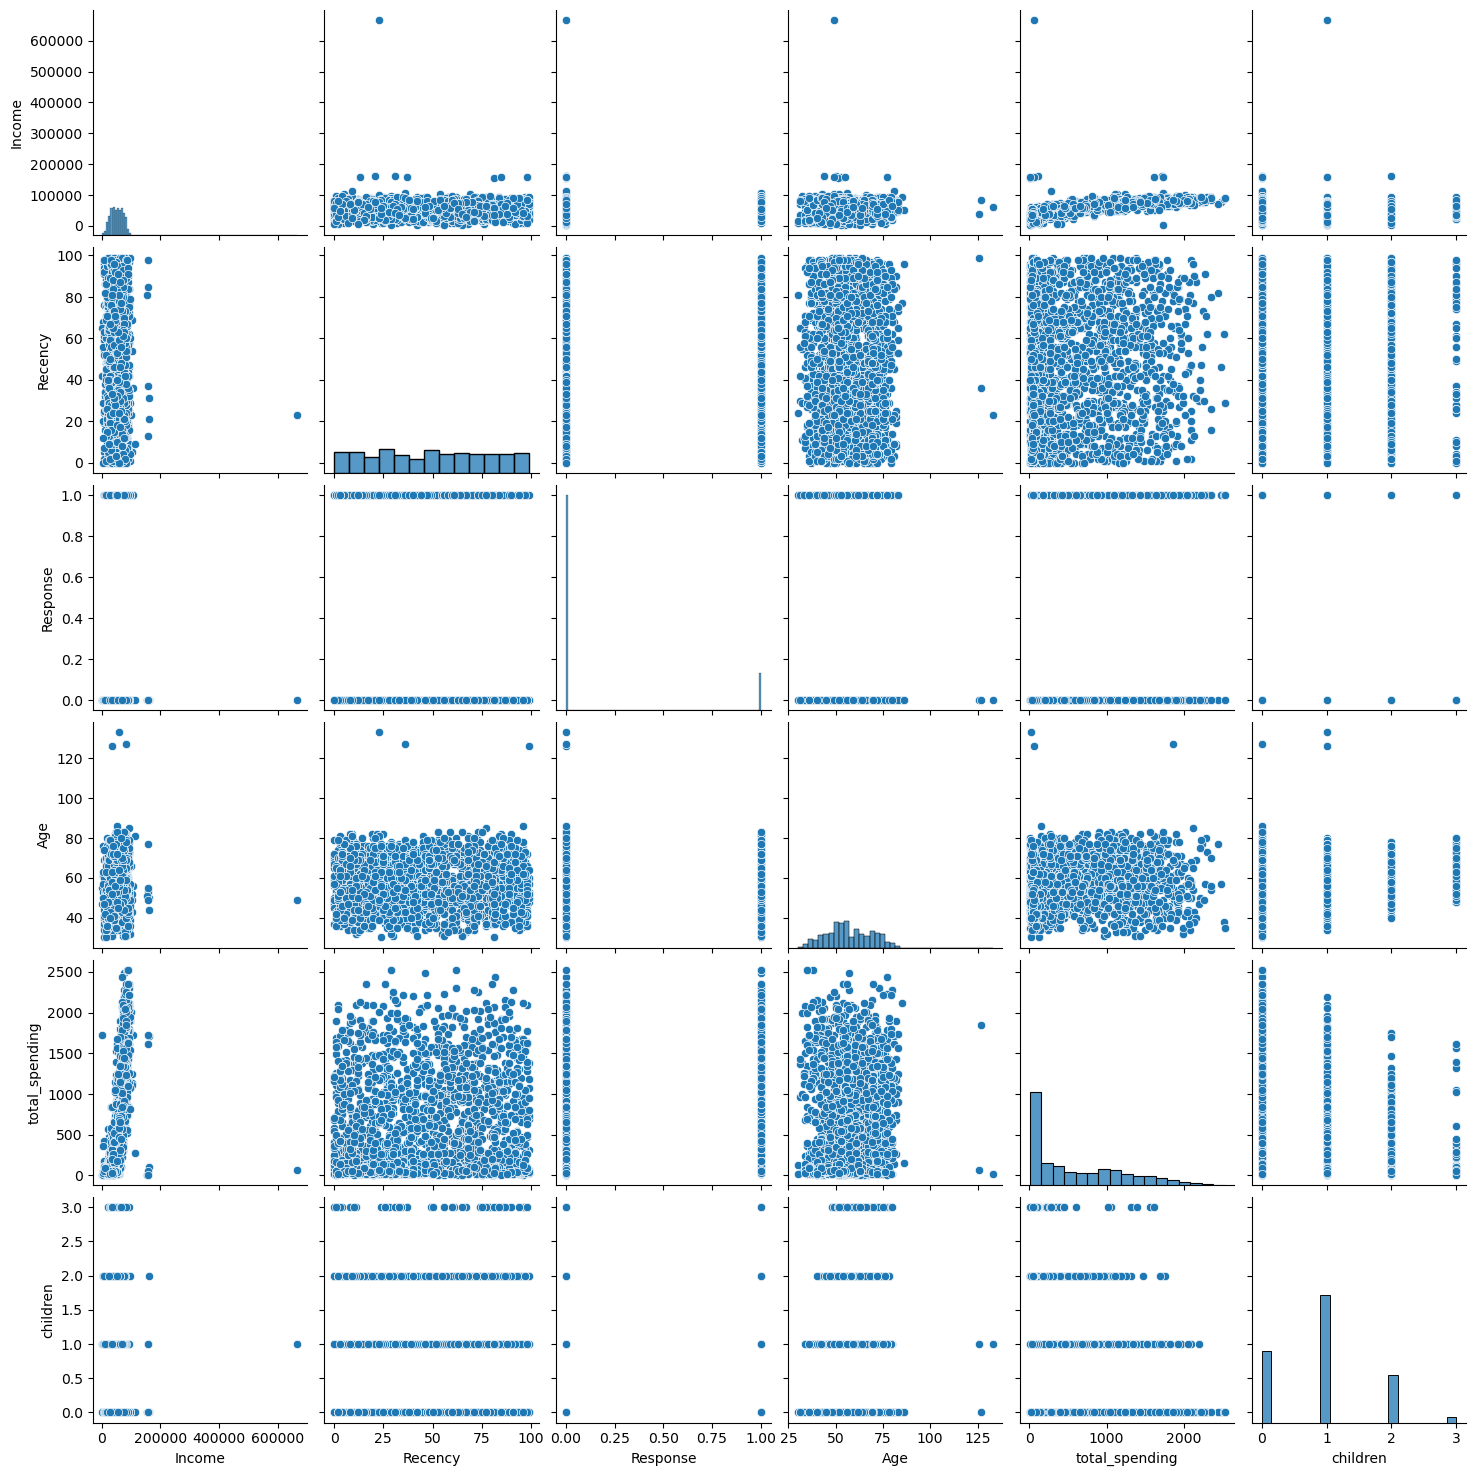

In [22]:
cols=["Income","Recency","Response","Age","total_spending","children"]
import seaborn as sns
sns.pairplot(df[cols])

In [23]:
df=df[(df["Income"]<600000)]
df=df[(df["Age"]<90)]
print("data size without outliers:",len(df))

data size without outliers: 2236


<Axes: >

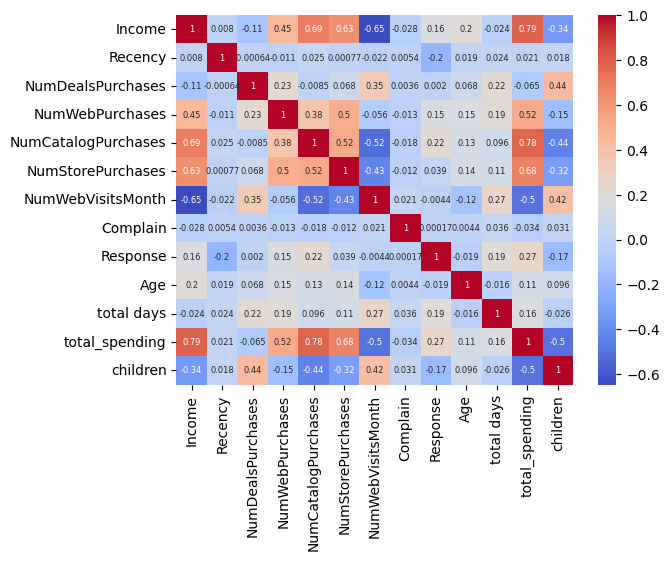

In [24]:
# Heatmap
corr=df.corr(numeric_only=True)
sns.heatmap(
    corr,
    annot=True,
    annot_kws={"size":6},
    cmap="coolwarm"
)

# OneHotEncoder

In [25]:
from sklearn.preprocessing import OneHotEncoder

In [26]:
ohe=OneHotEncoder()
cat_cols=["Education","Marital_Status"]

In [28]:
enc_cols=ohe.fit_transform(df[cat_cols])

In [29]:
enc_df=pd.DataFrame(enc_cols.toarray(),columns=ohe.get_feature_names_out(cat_cols),index=df.index)

In [30]:
df_encoded=pd.concat([df.drop(columns=cat_cols),enc_df],axis=1)

In [31]:
df_encoded.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,total days,total_spending,children,Education_graduate,Education_postgraduate,Education_undergraduate,Marital_Status_alone,Marital_Status_partner
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,0.0,1.0,0.0,1.0,0.0
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,0.0,1.0,0.0,1.0,0.0
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,0.0,1.0,0.0,0.0,1.0
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,0.0,1.0,0.0,0.0,1.0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0


In [32]:
from sklearn.preprocessing import StandardScaler

In [33]:
x=df_encoded

In [34]:
scaler=StandardScaler()
x_scaled=scaler.fit_transform(x)

In [35]:
x_scaled

array([[ 0.2885133 ,  0.30685572,  0.34873831, ..., -0.35877969,
         1.3476353 , -1.3476353 ],
       [-0.26243786, -0.38397129, -0.16869955, ..., -0.35877969,
         1.3476353 , -1.3476353 ],
       [ 0.91799157, -0.7984675 , -0.68613742, ..., -0.35877969,
        -0.74204052,  0.74204052],
       ...,
       [ 0.23446459,  1.44672029, -0.68613742, ..., -0.35877969,
         1.3476353 , -1.3476353 ],
       [ 0.80737157, -1.42021181, -0.16869955, ..., -0.35877969,
        -0.74204052,  0.74204052],
       [ 0.04237444, -0.31488859,  0.34873831, ..., -0.35877969,
        -0.74204052,  0.74204052]], shape=(2236, 18))

In [36]:
 from sklearn.decomposition import PCA

In [37]:
pca=PCA(n_components=3)


In [38]:
model=pca.fit_transform(x_scaled)

In [39]:
pca.explained_variance_ratio_

array([0.2320002 , 0.11419287, 0.10454924])

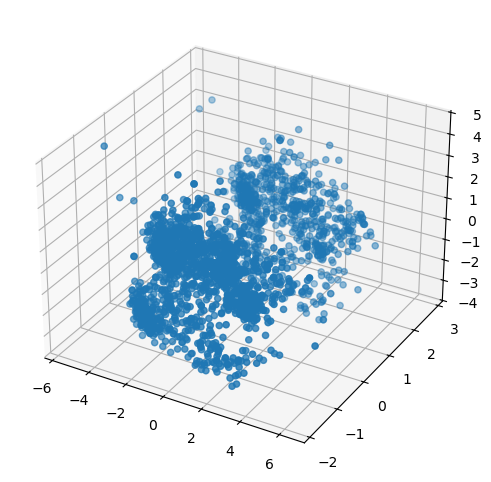

In [40]:
fig=plt.figure(figsize=(8,6))

ax= fig.add_subplot(111,projection="3d")

ax.scatter(model[:,0],model[:,1],model[:,2])

In [41]:
pca.explained_variance_ratio_

array([0.2320002 , 0.11419287, 0.10454924])

# Elbow Method

In [ ]:
from sklearn.cluster import KMeans
from kneed import KneeLocator
wcss=[]
for k in range(1,11):
    kmeans=KMeans(n_clusters=k,random_state=42)
    kmeans.fit_predict(model)
    wcss.append(kmeans.inertia_)

In [53]:
knee=KneeLocator(range(1,11),wcss,curve="convex",direction= "decreasing")
print("optimal k:",knee.elbow)

optimal k: 4


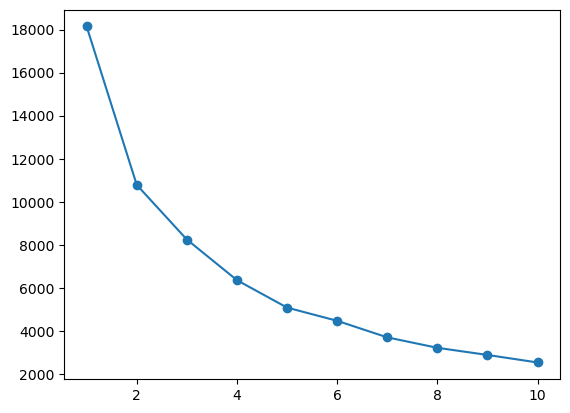

In [54]:
plt.plot(range(1,11),wcss,marker="o")

# Silouette Score

In [ ]:
from sklearn.metrics import silhouette_score
scores=[]
for k in range(2,11):
    kmeans=KMeans(n_clusters=k,random_state=42)
    label=kmeans.fit_predict(model)
    score=silhouette_score(model,label)
    scores.append(score)

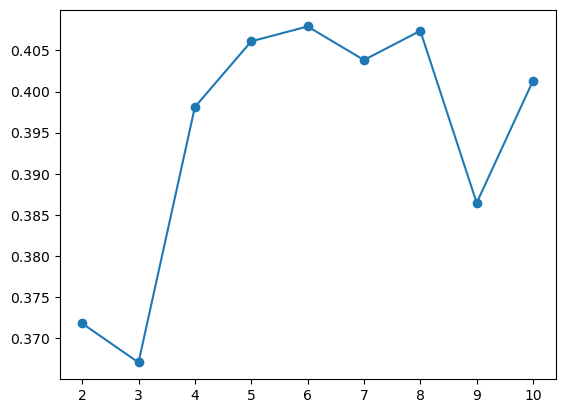

In [60]:
plt.plot(range(2,11),scores,marker="o")

# Combining Graph

Text(0, 0.5, 'SS')

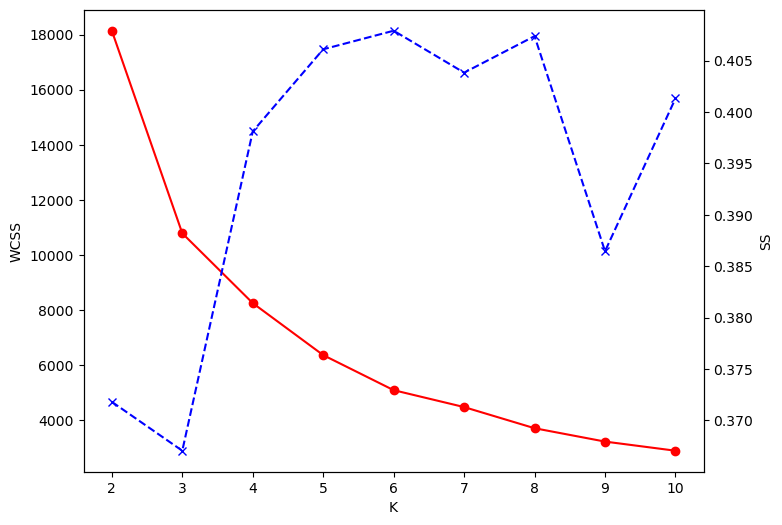

In [71]:
k_range=range(2,11)
fig,ax1=plt.subplots(figsize=(8,6))
ax1.plot(k_range,wcss[:len(k_range)],marker="o",color="red")
ax1.set_xlabel("K")
ax1.set_ylabel("WCSS")
ax2=ax1.twinx()
ax2.plot(k_range, scores[:len(k_range)], marker="x",color="blue",linestyle ="--")
ax2.set_ylabel("SS")

# Clustering

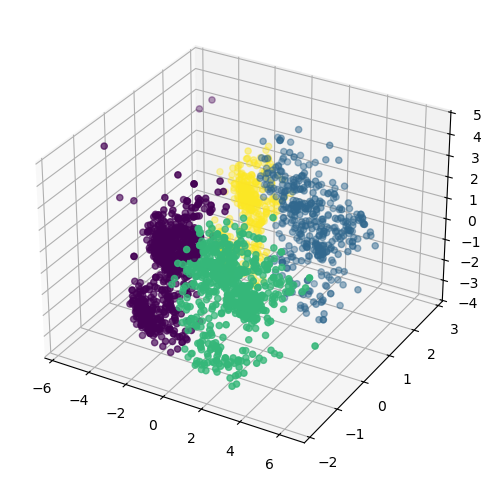

In [74]:
from sklearn.cluster import AgglomerativeClustering
agg=AgglomerativeClustering(n_clusters=4,linkage="ward")
label_agg=agg.fit_predict(model)
fig=plt.figure(figsize=(8,6))
ax= fig.add_subplot(111,projection="3d")
ax.scatter(model[:,0],model[:,1],model[:,2],c=label_agg)

# characterisation of clustering

In [89]:

x["cluster"]=label_agg


In [90]:
x.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,total days,total_spending,children,Education_graduate,Education_postgraduate,Education_undergraduate,Marital_Status_alone,Marital_Status_partner,cluster
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,0.0,1.0,0.0,1.0,0.0,1
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,0.0,1.0,0.0,1.0,0.0,3
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,0.0,1.0,0.0,0.0,1.0,2
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,0.0,1.0,0.0,0.0,1.0,0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0,0


<Axes: xlabel='cluster', ylabel='count'>

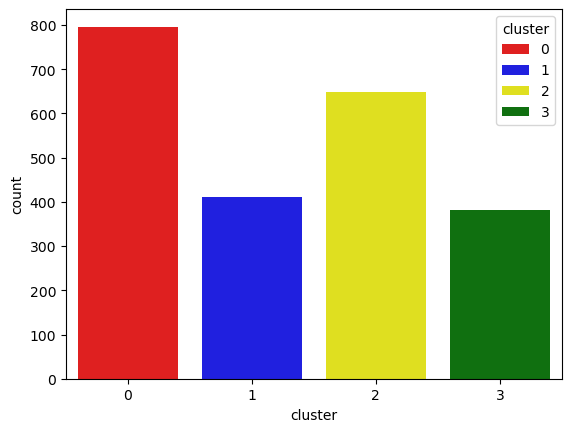

In [91]:
pal=["red","blue","yellow","green",]
sns.countplot(x=x["cluster"],palette=pal,hue=x["cluster"])

<Axes: xlabel='total_spending', ylabel='Income'>

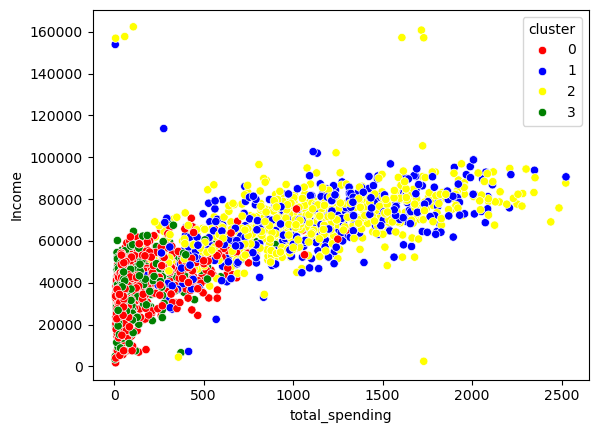

In [93]:
sns.scatterplot(x=x["total_spending"],y=x["Income"],hue=x["cluster"],palette=pal)

In [92]:
cluster_summary=x.groupby("cluster").mean()
print(cluster_summary)

               Income    Recency  NumDealsPurchases  NumWebPurchases  \
cluster                                                                
0        36883.130983  48.913317           2.611809         2.788945   
1        67455.061452  49.221411           2.274939         5.761557   
2        70169.826014  49.239198           2.100309         5.666667   
3        35784.181776  49.217848           2.167979         2.309711   

         NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  Complain  \
cluster                                                                        
0                   0.752513           3.709799           6.604271  0.008794   
1                   4.586375           8.075426           4.214112  0.007299   
2                   4.961420           8.367284           3.797840  0.009259   
3                   0.671916           3.320210           6.412073  0.010499   

         Response        Age  total days  total_spending  children  \
cluster         